In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer



In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.sample(5)

,Survived,Age,Fare
841,0,16.0,10.5000
573,1,NaN,7.7500
411,0,NaN,6.8583
878,0,NaN,7.8958
209,1,40.0,31.0000


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [7]:
df.shape

(714, 3)

In [8]:
df.sample(5)

,Survived,Age,Fare
794,0,25.0,7.8958
569,1,32.0,7.8542
123,1,32.5,13.0000
487,0,58.0,29.7000
632,1,32.0,30.5000


In [9]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [11]:
x,y

(      Age     Fare
 0    22.0   7.2500
 1    38.0  71.2833
 2    26.0   7.9250
 3    35.0  53.1000
 4    35.0   8.0500
 ..    ...      ...
 885  39.0  29.1250
 886  27.0  13.0000
 887  19.0  30.0000
 889  26.0  30.0000
 890  32.0   7.7500
 
 [714 rows x 2 columns],
 0      0
 1      1
 2      1
 3      1
 4      0
       ..
 885    0
 886    0
 887    1
 889    1
 890    0
 Name: Survived, Length: 714, dtype: int64)

In [12]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [14]:
X_train.head()

,Age,Fare
37,21.0,8.0500
58,5.0,27.7500
57,28.5,7.2292
94,59.0,7.2500
209,40.0,31.0000


In [15]:
clf=DecisionTreeClassifier()

In [16]:
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [17]:
accuracy_score(y_test,y_pred)

0.6046511627906976

In [18]:
np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy'))

0.6330790297339594

**There are many ways to do binning (Uniform, Percentile, K-Means) choose whichever you want to do and just try out with every binning types**

In [19]:
##Equal-Frequency Binning/Quantile Binning/Percentile Binning

#K_Age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
#K_Fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

##Clustering Based Binning/K-Means Binning

#K_Age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')
#K_Fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')

#Equal-Width Binning/Uniform Binning
K_Age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='uniform')
K_Fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='uniform')

In [20]:
trf=ColumnTransformer([('Age',K_Age,['Age']),('Fare',K_Fare,['Fare'])])

In [21]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [22]:
trf.named_transformers_['Age'].bin_edges_

array([array([ 0.67 ,  8.603, 16.536, 24.469, 32.402, 40.335, 48.268, 56.201,
              64.134, 72.067, 80.   ])                                       ],
      dtype=object)

In [23]:
trf.named_transformers_['Fare'].bin_edges_

array([array([  0. ,  26.3,  52.6,  78.9, 105.2, 131.5, 157.8, 184.1, 210.4,
              236.7, 263. ])                                                ],
      dtype=object)

In [25]:
output=pd.DataFrame({
    'age':X_train['Age'],
    'age_bin':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_bin':X_train_trf[:,1]
})

In [26]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['Age'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['Fare'].bin_edges_[0].tolist())

In [27]:
output.sample(5)

,age,age_bin,fare,fare_bin,age_labels,fare_labels
331,45.5,5.0,28.5000,1.0,"(40.335, 48.268]","(26.3, 52.6]"
800,34.0,4.0,13.0000,0.0,"(32.402, 40.335]","(0.0, 26.3]"
532,17.0,2.0,7.2292,0.0,"(16.536, 24.469]","(0.0, 26.3]"
866,27.0,3.0,13.8583,0.0,"(24.469, 32.402]","(0.0, 26.3]"
286,30.0,3.0,9.5000,0.0,"(24.469, 32.402]","(0.0, 26.3]"


In [28]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)
accuracy_score(y_test,y_pred2)

0.6372093023255814

In [31]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6303012519561815

**A Function to help you execute different types of Binning by only passing two parameters (No. of Bins,Binnign Method)**

In [36]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

c:\Users\DELL\miniconda3\envs\placement_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\DELL\miniconda3\envs\placement_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.630320813771518


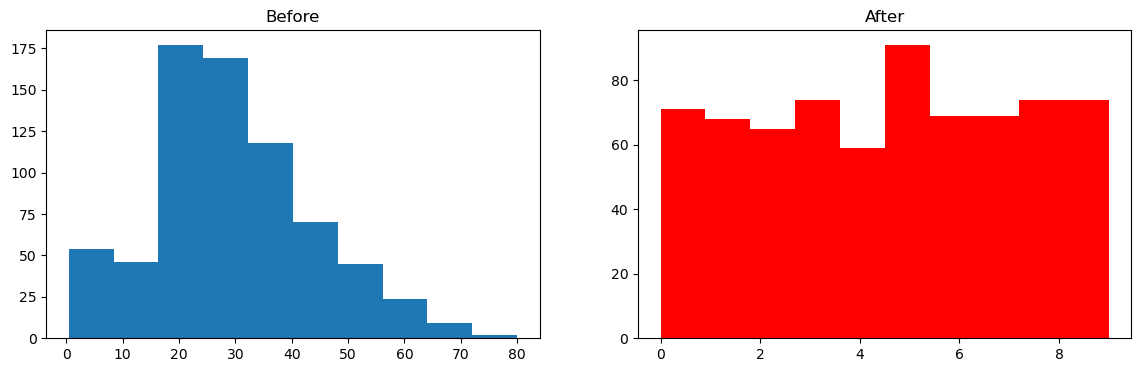

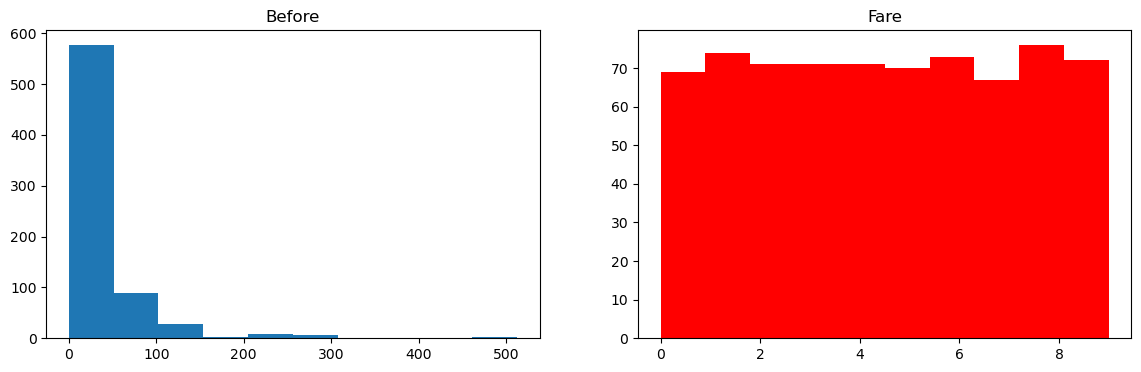

In [37]:
discretize(10,'quantile')